# Understanding the Customer Problem

Many companies receive thousands of customer support messages every week through channels such as email, support forms, and online platforms. These messages often contain valuable feedback about product issues, bugs, or user frustrations.

However, manually reading and analyzing thousands of messages is extremely time-consuming and inefficient. As a result, companies struggle to identify the most common problems their customers are facing.

For example, customers might repeatedly complain about login issues, payment errors, or software crashes, but these patterns may remain hidden inside large volumes of text.

To solve this problem, companies can use Natural Language Processing (NLP) techniques to automatically analyze customer messages.

In this project, we apply **Latent Semantic Analysis (LSA)** using **Singular Value Decomposition (SVD)** to discover hidden topics inside a large collection of text documents.

This approach helps organizations:

- Identify the most common types of customer complaints
- Detect repeated issues reported by multiple users
- Group similar complaints together
- Understand the main themes present in customer feedback

By automatically discovering topics and similarities between documents, companies can improve their support systems, prioritize urgent issues, and improve product quality.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Dataset
from datasets import load_dataset

# NLTK setup
nltk.download("stopwords")
nltk.download('wordnet')
nltk.download('omw-1.4')

# Skip warnings
import warnings
warnings.filterwarnings("ignore")

c:\Users\EL3ATTY\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\EL3ATTY\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\EL3ATTY\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\EL3ATTY\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Data Understanding

The dataset used in this project is the **20 Newsgroups dataset**, which is a widely used benchmark dataset for text classification and natural language processing research.

It contains thousands of documents collected from online discussion forums called "newsgroups".

Each document represents a message written by a user in a discussion group related to a specific topic.

Examples of topics include:

- computer technology
- politics
- religion
- sports
- science

For this analysis, we randomly selected approximately **4000 documents** from the dataset.

Although this dataset contains forum discussions, it can represent a real-world scenario where companies receive large volumes of customer messages or support tickets.

Each message can be treated as a **customer complaint or support request**, making the dataset suitable for demonstrating how topic discovery techniques can help analyze customer feedback.

In [2]:
dataset = load_dataset("SetFit/20_newsgroups")

df = dataset["train"].to_pandas()
df.head()

Repo card metadata block was not found. Setting CardData to empty.


,text,label,label_text
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


In [3]:
df = df.sample(4000, random_state=42).reset_index(drop=True)

print("Number of documents:", len(df))
df.head()

Number of documents: 4000


,text,label,label_text
0,Could someone please post any info on these sy...,4,comp.sys.mac.hardware
1,\n\n Don't bother if you have CPBackup or ...,2,comp.os.ms-windows.misc
2,"5.25"" Internal Low density disk drive.\n\nMono...",6,misc.forsale
3,"Hi,\n\nIn Canada, any gun that enters a Nation...",16,talk.politics.guns
4,\nDoesn't it also have the Statue of Liberty o...,10,rec.sport.hockey


### Document Length Analysis

Analyzing document length helps us understand the structure of the dataset.

Some messages are short, while others contain long discussions or detailed explanations.

This behavior is similar to real-world customer support data. Some users may report issues briefly, while others provide detailed descriptions of their problems.

Understanding document length distribution helps us anticipate potential challenges when processing the text data.

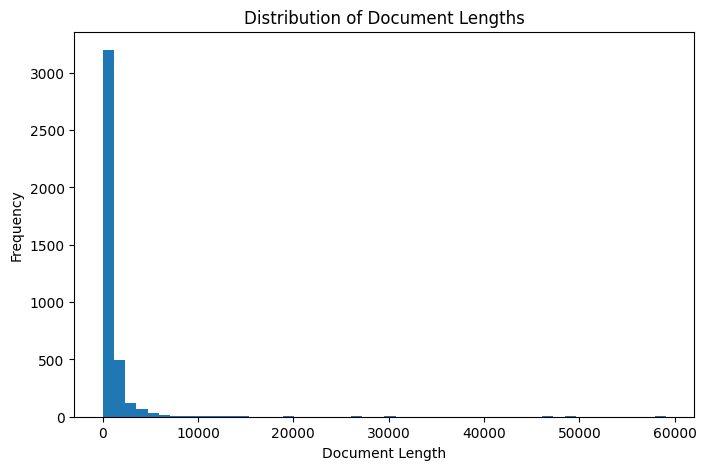

In [4]:
df["length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df["length"], bins=50)
plt.title("Distribution of Document Lengths")
plt.xlabel("Document Length")
plt.ylabel("Frequency")
plt.show()

### Word Frequency Analysis

Examining the most frequent words provides insight into the types of discussions present in the dataset.

Some commonly appearing words may indicate recurring topics or themes within the messages.

In real-world customer support data, frequent words such as "error", "login", or "payment" might reveal common technical issues faced by users.

This type of exploratory analysis helps data scientists gain an initial understanding of the dataset before applying more advanced techniques.

In [5]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(df["text"])

words = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

freq_df = pd.DataFrame({
    "word": words,
    "count": counts
}).sort_values(by="count", ascending=False)

freq_df

,word,count
0,ax,30132
10,max,2208
12,people,1446
8,like,1370
2,don,1341
6,just,1338
7,know,1256
15,think,1086
16,time,1012
17,use,1011


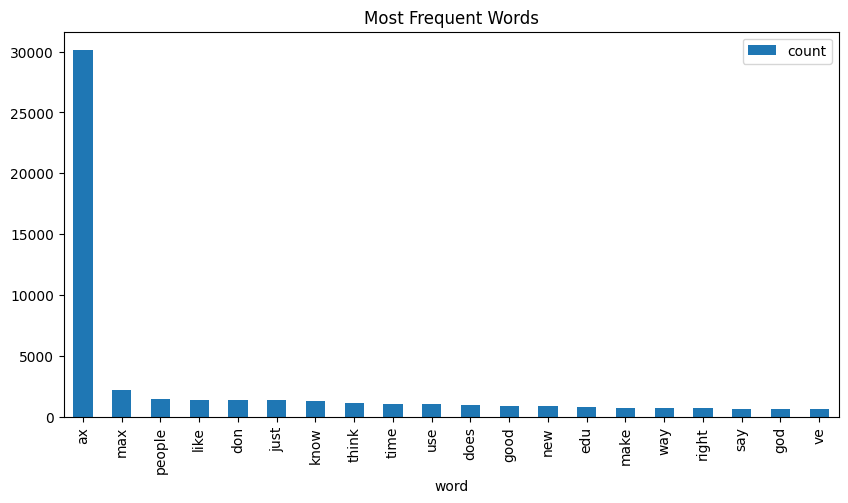

In [6]:
freq_df.plot.bar(x="word", y="count", figsize=(10,5))
plt.title("Most Frequent Words")
plt.show()

# Text Preprocessing

Raw text often contains noise such as punctuation, numbers, repeated entries, missing values, and common words that do not contribute significant meaning.

To prepare the text for analysis, several preprocessing steps were applied:

- **Converting all text to lowercase**  
- **Removing punctuation, numbers, and special characters**  
- **Tokenizing the text into individual words**  
- **Removing common stopwords** such as "the", "and", and "is"  
- **Lemmatizing words** to reduce them to their base form (e.g., "running" → "run")  
- **Handling missing values** by identifying and optionally removing null entries  
- **Removing duplicate entries** to ensure each text sample is unique  

These steps help reduce noise, standardize the text, and improve the quality of the representation used for machine learning and natural language processing tasks.

In [7]:
print("Null values in each column:")
print(df.isnull().sum())

duplicate_count = df.duplicated(subset=["text"]).sum()
print(f"\nNumber of duplicate rows in 'text': {duplicate_count}")

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

Null values in each column:
text          0
label         0
label_text    0
length        0
dtype: int64

Number of duplicate rows in 'text': 82


In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and non-letter characters
    text = re.sub(r"[^a-z\s]", "", text)
    
    # Tokenize (split by whitespace)
    tokens = text.split()
    
    # Remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    # Rejoin tokens
    return " ".join(tokens)

# Apply preprocessing
df["clean_text"] = df["text"].apply(preprocess)

df[["text","clean_text"]].head(10)
df.to_csv("dataset_cleaned.csv", index=False)

# Feature Engineering using TF-IDF

Machine learning models cannot directly process raw text, so we must convert the documents into numerical representations.

In this project we use **TF-IDF (Term Frequency – Inverse Document Frequency)** to represent the importance of each word in a document.

The resulting matrix is called a **Document-Term Matrix**.

In this matrix:

- Each **row** represents a document
- Each **column** represents a word (term)
- Each **value** represents the TF-IDF score of a word in a document

TF-IDF helps highlight words that are important within specific documents while reducing the influence of very common words across the dataset.

In [9]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (3918, 5000)


# Applying Singular Value Decomposition (SVD)

The TF-IDF matrix is typically very large and sparse, containing thousands of word features.

To uncover hidden semantic relationships in the data, we apply **Singular Value Decomposition (SVD)**.

SVD decomposes the document-term matrix into three matrices that capture relationships between documents and terms.

This process allows us to reduce the dimensionality of the dataset while preserving important semantic information.

In this project, we reduced the original feature space to **100 latent semantic components**.

These components represent underlying themes or topics present in the documents.

In [10]:
k = 100

svd = TruncatedSVD(n_components=k, random_state=42)

X_reduced = svd.fit_transform(X)

print("Reduced Matrix Shape:", X_reduced.shape)

Reduced Matrix Shape: (3918, 100)


# Topic Discovery

Each latent component generated by SVD represents a potential hidden topic within the dataset.

By examining the words with the highest weights in each component, we can interpret the meaning of the topics.

For example:

Topic Example Interpretation

Topic 1: login, password, account, user  
→ Authentication related discussions

Topic 2: space, nasa, orbit, satellite  
→ Space and astronomy discussions

These discovered topics help organizations understand the main themes present in large collections of text data.

In [11]:
terms = tfidf.get_feature_names_out()

for i, comp in enumerate(svd.components_[:10]):

    terms_comp = zip(terms, comp)

    sorted_terms = sorted(terms_comp, key=lambda x: x[1], reverse=True)[:10]

    print("Topic", i+1)
    print([t[0] for t in sorted_terms])
    print()

Topic 1
['would', 'one', 'know', 'dont', 'like', 'get', 'people', 'think', 'im', 'time']

Topic 2
['window', 'thanks', 'card', 'file', 'email', 'please', 'anyone', 'drive', 'program', 'do']

Topic 3
['god', 'thanks', 'please', 'email', 'anyone', 'know', 'address', 'christian', 'advance', 'file']

Topic 4
['window', 'file', 'god', 'card', 'do', 'key', 'people', 'use', 'program', 'christian']

Topic 5
['gordon', 'gebcadredslpittedu', 'surrender', 'chastity', 'njxp', 'shameful', 'intellect', 'skepticism', 'bank', 'soon']

Topic 6
['key', 'chip', 'clipper', 'government', 'would', 'phone', 'encryption', 'escrow', 'file', 'algorithm']

Topic 7
['window', 'file', 'game', 'team', 'program', 'player', 'year', 'do', 'run', 'win']

Topic 8
['car', 'bike', 'window', 'problem', 'drive', 'mile', 'im', 'engine', 'thing', 'light']

Topic 9
['card', 'driver', 'video', 'monitor', 'window', 'would', 'know', 'car', 'mode', 'vga']

Topic 10
['would', 'know', 'im', 'anyone', 'dont', 'like', 'think', 'drive'

# Finding Similar Customer Complaints

After reducing the document representations using SVD, we can measure similarity between documents using cosine similarity.

Documents with high similarity scores likely discuss the same issue or topic.

In a real customer support system, this capability can be used to:

- detect duplicate support tickets
- identify recurring technical issues
- group similar complaints together
- improve automated response systems

This allows companies to better manage large volumes of customer feedback and quickly identify widespread problems.

In [12]:
similarity_matrix = cosine_similarity(X_reduced)

similarity_matrix.shape

(3918, 3918)

In [13]:
doc1 = 100
doc2 = 250

print("Similarity:", similarity_matrix[doc1, doc2])

print("\nDocument 1:\n", df["text"][doc1][:400])
print("\nDocument 2:\n", df["text"][doc2][:400])

Similarity: 0.039702652517371304

Document 1:
 We here at Utah State University Cooperative Extension have been using
W4Wg for a while now.  We wanted to talk to the internet with the mail
package so we got the smtp gateway.  You also need a tcp/ip transport
package on top of that which is utterly stupid but that's what they
require to get the smtp gateway to work.  You need a dedicated pc
for the gateway and if you are looking at remote acces

Document 2:
 

OK: So you were a naive teen.


	Wrong: 1915 and if you do your homework, 1909.
But he was born LAST century (1883).

